## Лабораторная работа EDA-1

### О задании

В этом домашнем задании вы получите опыт подготовки данных и EDA (Exploratory Data Analysis), приблизившись к реальной работе с данными с помощью уже знакомых вам инструментов: numpy, pandas, matplotlib и seaborn.

Вы будет работать с задачей кредитного скоринга (оценка надёжности клиента). Предоставляются данные о 1000 клиентов, про которых известно около 20 признаков и положительная или отрицательная оценка в качестве кредитуемого. Эти данные нужно будет подготовить, исследовать (в том числе с помощью средств визуализации) и даже попробовать предложить какую-нибудь формулу для условной оценки надёжности клиентов исходя из предоставленных данных. Описание данных:
https://www.rdocumentation.org/packages/evtree/versions/1.0-8/topics/GermanCredit

Каждый построенный график необходимо красиво оформить - для этого требуется как минимум указать его название, а также отметить, что изображено по каждой из осей.
Также по каждому графику ожидается небольшой комментарий с выводами.

*Функции, которые могут пригодиться при оформлении графиков: `.show()`, `.title()`, `.xlabel()`, `.ylabel()`*

In [5]:
import pandas as pd

### Задание 1

Прочитайте средствами pandas файл с данными. Выведите базовое представление таблицы (первые 5 и последние 5 строк, размер).

In [7]:
df = pd.read_csv('german_credit.csv')
print(df.shape)
display(df.head(), df.tail())

(1000, 21)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,no checking account,18,all credits at this bank paid back duly,car (used),1049,unknown/no savings account,< 1 yr,< 20,female : non-single or male : single,none,...,car or other,21,none,for free,1,skilled employee/official,0 to 2,no,no,good
1,no checking account,9,all credits at this bank paid back duly,others,2799,unknown/no savings account,1 <= ... < 4 yrs,25 <= ... < 35,male : married/widowed,none,...,unknown / no property,36,none,for free,2-3,skilled employee/official,3 or more,no,no,good
2,... < 0 DM,12,no credits taken/all credits paid back duly,retraining,841,... < 100 DM,4 <= ... < 7 yrs,25 <= ... < 35,female : non-single or male : single,none,...,unknown / no property,23,none,for free,1,unskilled - resident,0 to 2,no,no,good
3,no checking account,12,all credits at this bank paid back duly,others,2122,unknown/no savings account,1 <= ... < 4 yrs,20 <= ... < 25,male : married/widowed,none,...,unknown / no property,39,none,for free,2-3,unskilled - resident,3 or more,no,yes,good
4,no checking account,12,all credits at this bank paid back duly,others,2171,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,...,car or other,38,bank,rent,2-3,unskilled - resident,0 to 2,no,yes,good


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
995,no checking account,24,no credits taken/all credits paid back duly,furniture/equipment,1987,unknown/no savings account,1 <= ... < 4 yrs,25 <= ... < 35,male : married/widowed,none,...,unknown / no property,21,none,for free,1,unskilled - resident,3 or more,no,no,bad
996,no checking account,24,no credits taken/all credits paid back duly,others,2303,unknown/no savings account,>= 7 yrs,< 20,male : married/widowed,co-applicant,...,unknown / no property,45,none,rent,1,skilled employee/official,0 to 2,no,no,bad
997,... >= 200 DM / salary for at least 1 year,21,all credits at this bank paid back duly,others,12680,... >= 1000 DM,>= 7 yrs,< 20,male : married/widowed,none,...,real estate,30,none,own,1,manager/self-empl./highly qualif. employee,0 to 2,yes (under customer name),no,bad
998,... < 0 DM,12,no credits taken/all credits paid back duly,furniture/equipment,6468,... >= 1000 DM,unemployed,25 <= ... < 35,male : married/widowed,none,...,real estate,52,none,rent,1,manager/self-empl./highly qualif. employee,0 to 2,yes (under customer name),no,bad
999,no checking account,30,no credits taken/all credits paid back duly,car (used),6350,... >= 1000 DM,>= 7 yrs,< 20,male : married/widowed,none,...,car or other,31,none,rent,1,skilled employee/official,0 to 2,no,no,bad


### Задание 2 

Определите, есть ли пропуски в данных. Разделите признаки на количественные, бинарные, порядковые и категориальные.

In [9]:
print("Пропуски:")
print(df.isnull().sum())

quantitative = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

binary = [col for col in categorical if df[col].nunique() == 2]
categorical = [col for col in categorical if col not in binary]

print(f"\nКоличественные: {quantitative}")
print(f"Бинарные: {binary}") 
print(f"Категориальные: {categorical}")

Пропуски:
status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

Количественные: ['duration', 'amount', 'age']
Бинарные: ['people_liable', 'telephone', 'foreign_worker', 'credit_risk']
Категориальные: ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job']


### Задание 3 

Выведите среднюю сумму кредита (колонка amount) в каждой категории (колонка purpose), воспользовавшись методом groupby.

In [11]:
df.groupby('purpose')['amount'].mean()

purpose
business               8209.333333
car (new)              5370.223301
car (used)             3066.983425
domestic appliances    2728.090909
furniture/equipment    2487.685714
others                 3062.948718
radio/television       1498.000000
repairs                3180.400000
retraining             4158.041237
vacation               1205.888889
Name: amount, dtype: float64

### Задание 4 


Какой процент клиентов моложе 30 лет (колонка age) снимает жилье (колонка housing)? А какой процент клиентов старше 40 лет снимает жилье?

In [13]:
young_rent = df[(df['age'] < 30) & (df['housing'] == 'rent')].shape[0] / df[df['age'] < 30].shape[0] * 100
old_rent = df[(df['age'] > 40) & (df['housing'] == 'rent')].shape[0] / df[df['age'] > 40].shape[0] * 100

print(f"Моложе 30 и снимают: {young_rent}%")
print(f"Старше 40 и снимают: {old_rent}%")

Моложе 30 и снимают: 66.66666666666666%
Старше 40 и снимают: 68.01470588235294%


### Задание 5 

 У скольких иностранцев (foreign_worker) число кредитов (number_credits) больше 3?

In [15]:
print("Уникальные значения number_credits:")
print(df['number_credits'].value_counts())

def convert_credits(value):
    if value == '>= 6':
        return 6
    elif '-' in value:
        return int(value.split('-')[0])
    else:
        return int(value)

df['number_credits_num'] = df['number_credits'].apply(convert_credits)

print(f"Иностранцев с числом кредитов > 3: {df[(df['foreign_worker'] == 'yes') & (df['number_credits_num'] > 3)].shape[0]}")

Уникальные значения number_credits:
number_credits
1       633
2-3     333
4-5      28
>= 6      6
Name: count, dtype: int64
Иностранцев с числом кредитов > 3: 1


### Задание 6 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Используя numpy и matplotlib, начнём с тренировки: постройте график функций $sin(x)$ и $cos(x)$ от $-\pi$ до $\pi$ из 100 точек c легендой и сеткой. Используйте для линий разные цвета, одна из них пусть будет пунктирной. Результат в этом и следующих заданиях на построение графиков должен получиться примерно как на картинке. Содержание подписей не должно обязательно совпадать, однако осмысленные подписи должны присутствовать на графиках.

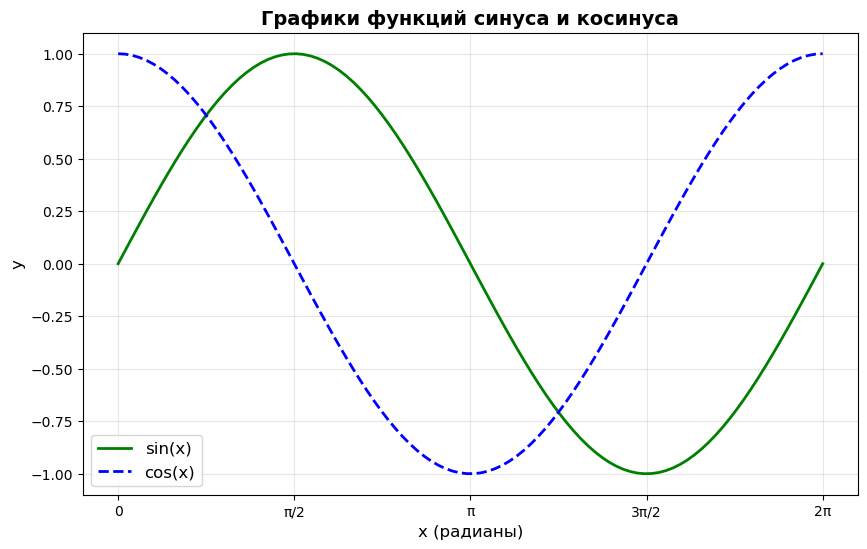

In [19]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

x = np.linspace(0, 2*np.pi, 100)

y1 = np.sin(x)
y2 = np.cos(x)


plt.figure(figsize=(10, 6))

plt.plot(x, y1, color='green', linestyle='-', linewidth=2, label='sin(x)')
plt.plot(x, y2, color='blue', linestyle='--', linewidth=2, label='cos(x)')

plt.title('Графики функций синуса и косинуса', fontsize=14, fontweight='bold')
plt.xlabel('x (радианы)', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], 
           ['0', 'π/2', 'π', '3π/2', '2π'])

plt.show()

Обе функции являются периодическими с периодом 2π

Синус начинается с 0, косинус - с 1

### Задание 7 

Рассмотрим сравнительное количество положительных и отрицательных кейсов в зависимости от размера текущего счёта. Постройте зеркальные горизонтальные гистограммы.

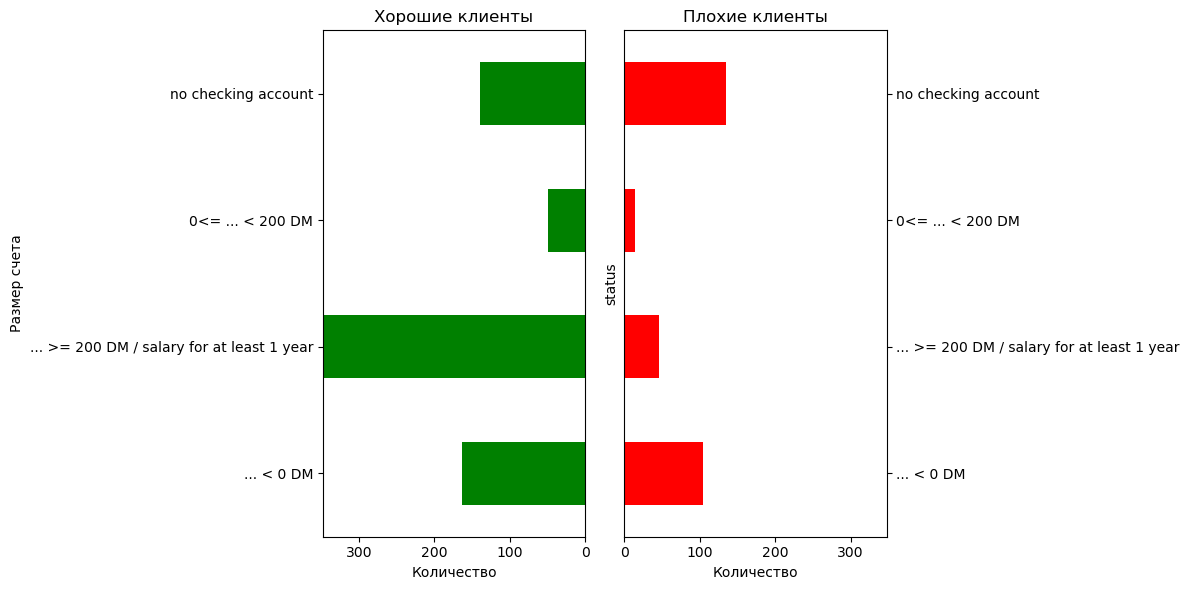

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

categories = sorted(df['status'].unique())

good_counts = df[df['credit_risk'] == 'good']['status'].value_counts().reindex(categories, fill_value=0)
good_counts.plot(kind='barh', ax=ax1, color='green')
ax1.set_title('Хорошие клиенты')
ax1.set_ylabel('Размер счета')
ax1.set_xlabel('Количество')
ax1.set_yticklabels(categories)

bad_counts = df[df['credit_risk'] == 'bad']['status'].value_counts().reindex(categories, fill_value=0)
bad_counts.plot(kind='barh', ax=ax2, color='red')
ax2.set_title('Плохие клиенты')
ax2.set_xlabel('Количество')
ax2.yaxis.tick_right()
ax2.set_yticklabels(categories)

max_count = max(good_counts.max(), bad_counts.max())
ax1.set_xlim(max_count, 0)
ax2.set_xlim(0, max_count)

plt.tight_layout()
plt.show()

Клиенты без счета ("no checking account") составляют большую группу в обеих категориях

Клиенты с положительным балансом счета чаще являются надежными заемщиками



### Задание 8 

In [23]:
import seaborn as sns

Теперь постройте гистограмму для сравнения количества положительных и отрицательных кейсов в зависимости от размера сберегательного счёта с помощью seaborn. Какой способ вам больше нравится с точки зрения трудоёмкости написания кода? А с точки зрения восприятия результата?

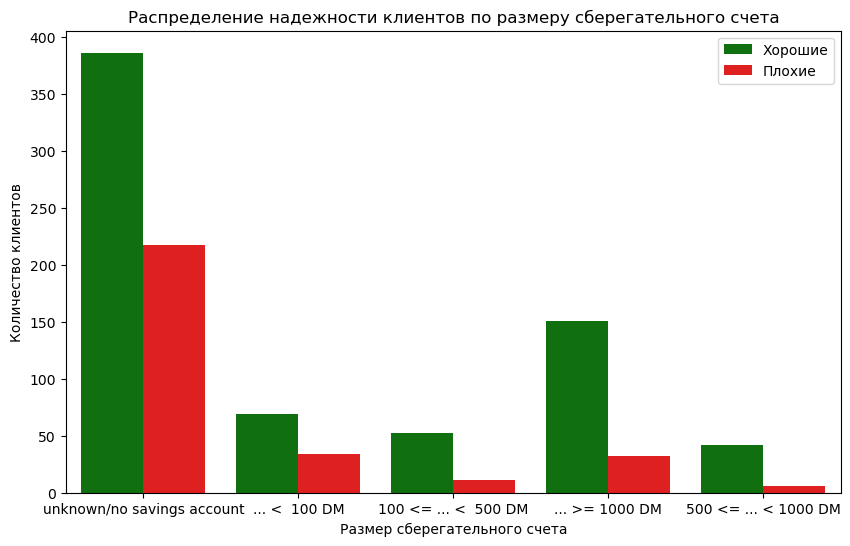

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='savings', hue='credit_risk', 
              hue_order=['good', 'bad'], palette={'good': 'green', 'bad': 'red'})
plt.title('Распределение надежности клиентов по размеру сберегательного счета')
plt.xlabel('Размер сберегательного счета')
plt.ylabel('Количество клиентов')
plt.legend(['Хорошие', 'Плохие'])
plt.show()

 График показывает зависимость между размером сберегательного счета и надежностью клиента. Заметно что клиенты с большими сбережениями (особенно категория ">= 1000 DM") значительно чаще являются надежными заемщиками.

### Задание 9

seaborn легко позволяет добавить ещё больше информации на один график. Для каждого размера сберегательного счёта мы можем оценить не только количество положительных и отрицательных кейсов, но и их распределение по возрасту, например. Постройте подходящую для этого визуализацию.

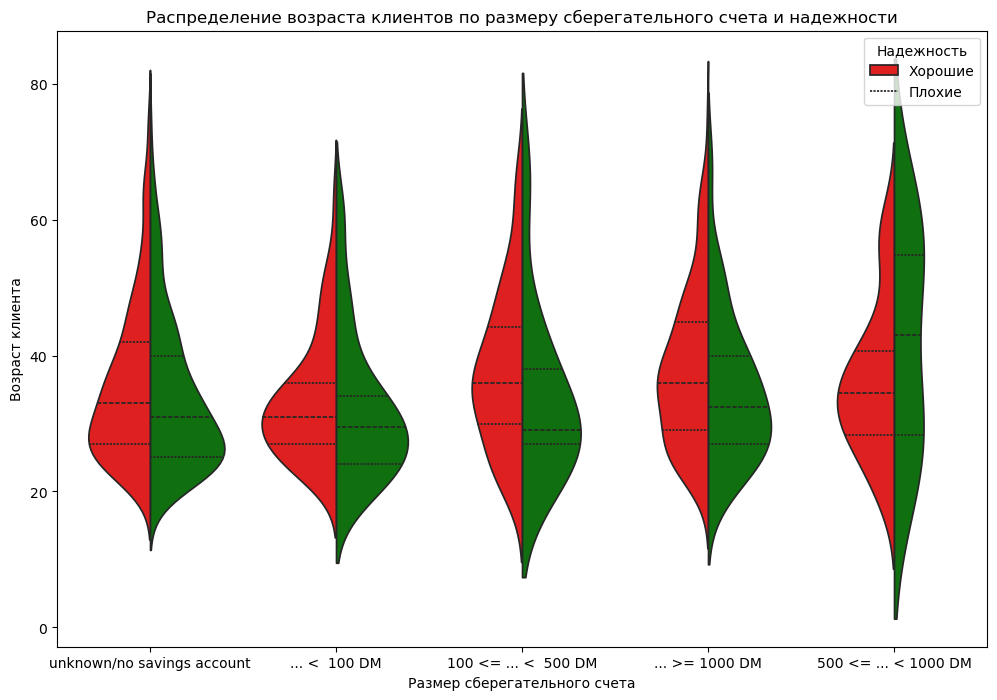

In [27]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=df, x='savings', y='age', hue='credit_risk', 
               hue_order=['good', 'bad'], palette={'green', 'red'},
               split=True, inner='quartile')  # inner='quartile' показывает только квартили
plt.title('Распределение возраста клиентов по размеру сберегательного счета и надежности')
plt.xlabel('Размер сберегательного счета')
plt.ylabel('Возраст клиента')
plt.legend(title='Надежность', labels=['Хорошие', 'Плохие'])
plt.show()

Комментарий: График показывает распределение возраста клиентов с отображением квартилей внутри violinplot. 

* Хорошо видны медианные значения возраста для каждой группы
* Можно сравнить форму распределения между надежными и ненадежными клиентами
* Сохраняется интуитивное понимание плотности данных через ширину violin

### Задание 10  

Заканчивая с гистограммами, посмотрим на распределение положительных и отрицательных кейсов по возрастам, разместив их друг над другом. Добавим распределение всех взятых кредитов.

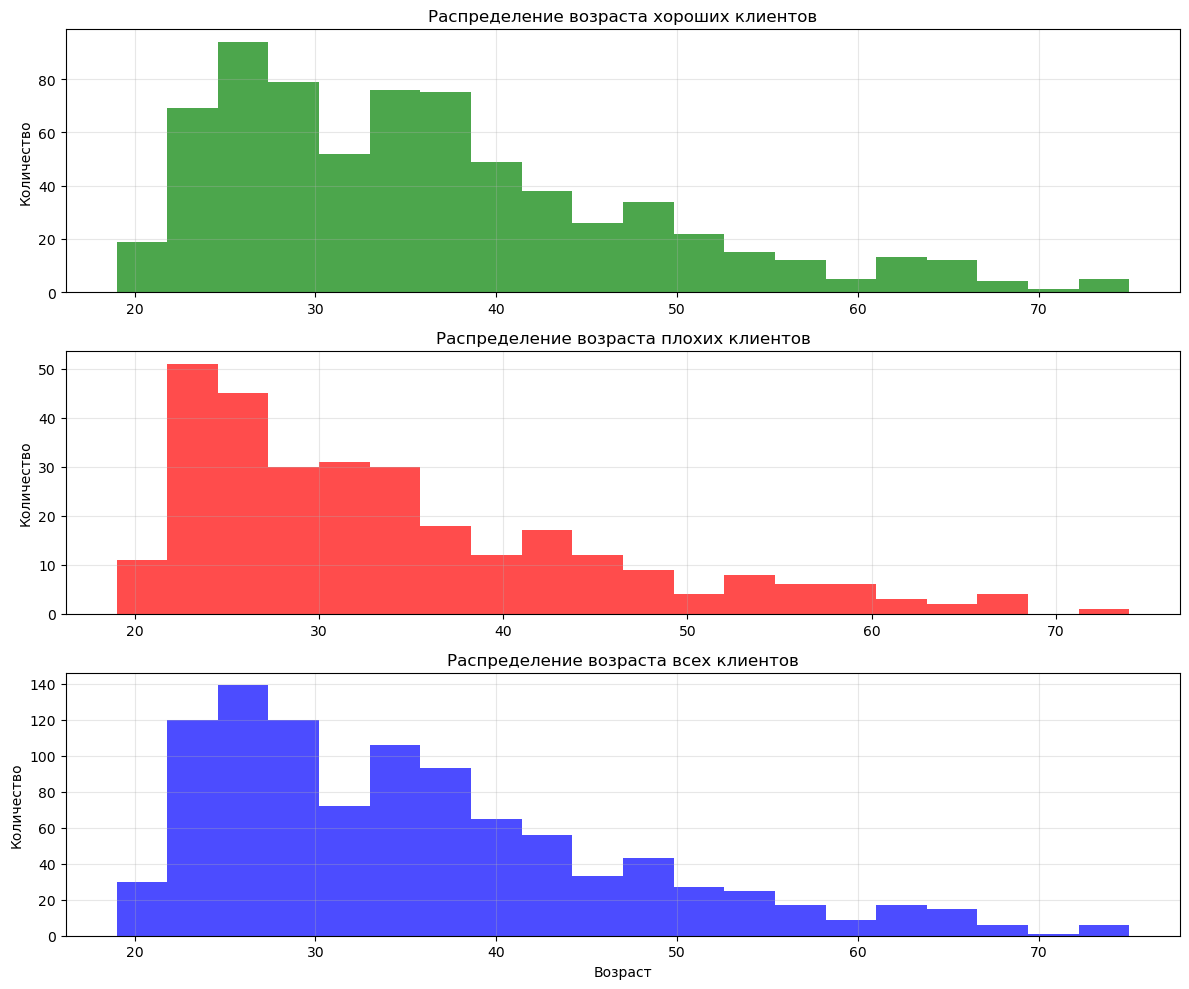

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

ax1.hist(df[df['credit_risk'] == 'good']['age'], bins=20, color='green', alpha=0.7)
ax1.set_title('Распределение возраста хороших клиентов')
ax1.set_ylabel('Количество')
ax1.grid(True, alpha=0.3)

ax2.hist(df[df['credit_risk'] == 'bad']['age'], bins=20, color='red', alpha=0.7)
ax2.set_title('Распределение возраста плохих клиентов')
ax2.set_ylabel('Количество')
ax2.grid(True, alpha=0.3)

ax3.hist(df['age'], bins=20, color='blue', alpha=0.7)
ax3.set_title('Распределение возраста всех клиентов')
ax3.set_xlabel('Возраст')
ax3.set_ylabel('Количество')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Молодые клиенты (до 30 лет) имеют более высокий риск неплатежа, в то время как клиенты 25-35 лет наиболее надежны.

### Задание 11

Не менее полезной иногда может быть диаграмма рассеяния. Постройте такую диаграмму с продолжительностью и размерами кредитов в качестве осей. Обозначьте положительные и отрицательные кейсы разными цветами.

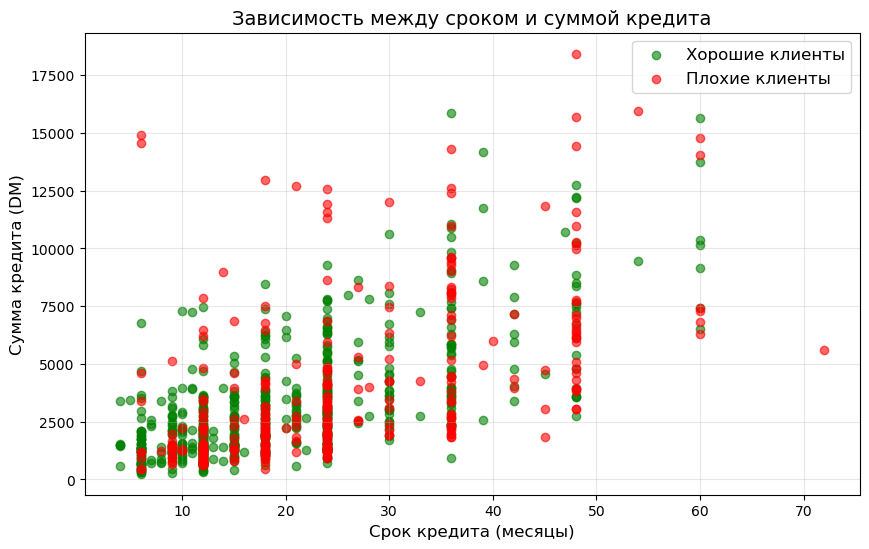

In [31]:
plt.figure(figsize=(10, 6))

good_clients = df[df['credit_risk'] == 'good']
bad_clients = df[df['credit_risk'] == 'bad']

plt.scatter(good_clients['duration'], good_clients['amount'], 
           color='green', alpha=0.6, label='Хорошие клиенты')
plt.scatter(bad_clients['duration'], bad_clients['amount'], 
           color='red', alpha=0.6, label='Плохие клиенты')

plt.title('Зависимость между сроком и суммой кредита', fontsize=14)
plt.xlabel('Срок кредита (месяцы)', fontsize=12)
plt.ylabel('Сумма кредита (DM)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.show()

Наблюдается положительная корреляция между сроком и суммой кредита - чем больше сумма, тем обычно дольше срок

### Задание 12 

Продвинемся глубже. Постройте 3D версию диаграммы рассеяния, добавив ось с возрастом.

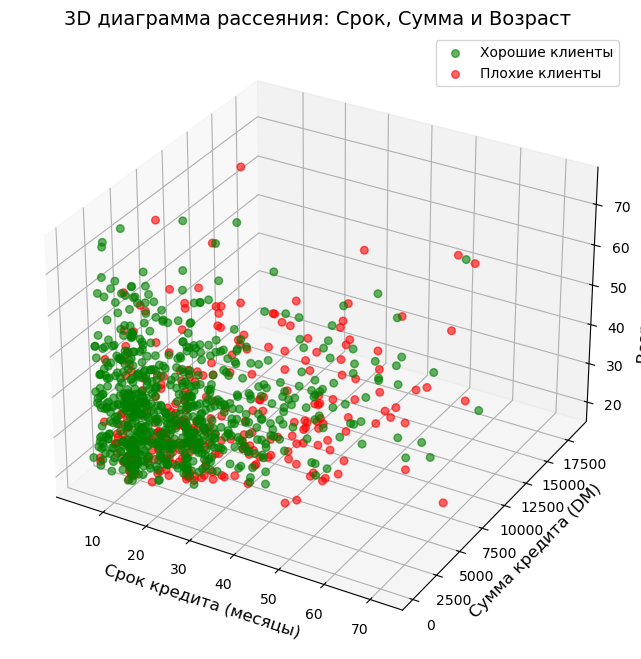

In [33]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

good_clients = df[df['credit_risk'] == 'good']
bad_clients = df[df['credit_risk'] == 'bad']

ax.scatter(good_clients['duration'], good_clients['amount'], good_clients['age'],
           color='green', alpha=0.6, label='Хорошие клиенты', s=30)
ax.scatter(bad_clients['duration'], bad_clients['amount'], bad_clients['age'],
           color='red', alpha=0.6, label='Плохие клиенты', s=30)

ax.set_title('3D диаграмма рассеяния: Срок, Сумма и Возраст', fontsize=14)
ax.set_xlabel('Срок кредита (месяцы)', fontsize=12)
ax.set_ylabel('Сумма кредита (DM)', fontsize=12)
ax.set_zlabel('Возраст клиента', fontsize=12)
ax.legend(fontsize=10)

plt.show()

Крупные кредиты (свыше 10000 DM) преимущественно берут клиенты старше 40 лет

### Задание 13 

Представьте все порядковые и бинарные признаки в виде числовых значений {0, ..., n - 1}, где n это количество значений признака. Избавьтесь от категориальных признаков.

In [35]:
df_encoded = df.copy()

categorical_columns = ['status', 'credit_history', 'purpose', 'savings', 
                      'employment_duration', 'personal_status_sex', 'other_debtors',
                      'property', 'other_installment_plans', 'housing', 
                      'job', 'telephone', 'foreign_worker']

for column in categorical_columns:
    if column in df_encoded.columns:
        df_encoded[column] = pd.Categorical(df_encoded[column]).codes

df_encoded['credit_risk'] = pd.Categorical(df_encoded['credit_risk']).codes

df_encoded = df_encoded.select_dtypes(include=[np.number])

print("Преобразованные данные:")
print(f"Размерность: {df_encoded.shape}")
print(f"Типы данных:\n{df_encoded.dtypes}")
print(f"\nПервые 5 строк:")
display(df_encoded.head())

Преобразованные данные:
Размерность: (1000, 18)
Типы данных:
status                      int8
duration                   int64
credit_history              int8
purpose                     int8
amount                     int64
savings                     int8
employment_duration         int8
personal_status_sex         int8
other_debtors               int8
property                    int8
age                        int64
other_installment_plans     int8
housing                     int8
job                         int8
telephone                   int8
foreign_worker              int8
credit_risk                 int8
number_credits_num         int64
dtype: object

Первые 5 строк:


,status,duration,credit_history,purpose,amount,savings,employment_duration,personal_status_sex,other_debtors,property,age,other_installment_plans,housing,job,telephone,foreign_worker,credit_risk,number_credits_num
0,3,18,0,2,1049,4,2,0,2,1,21,1,0,1,0,0,1,1
1,3,9,0,5,2799,4,0,3,2,3,36,1,0,1,0,0,1,2
2,0,12,4,8,841,0,1,0,2,3,23,1,0,3,0,0,1,1
3,3,12,0,5,2122,4,0,3,2,3,39,1,0,3,0,1,1,2
4,3,12,0,5,2171,4,0,3,2,1,38,0,2,3,0,1,1,2


### Задание 14 

По результатам предыдущего задания у вас должна получиться таблица, в которой все признаки так или иначе представлены числовыми значениями. Попробуйте придумать на основе проведённых исследований данных какую-нибудь формулу, связывающую целевую переменную с признаками, не используя готовых инструментов машинного обучения. По желанию вы можете исключить ещё какие-то признаки, или, наоборот, сформировать новые на основе имеющихся. Возможно, вы захотите отмасштабировать большие наборы численных значений некоторых признаков с помощью интервалов. Цель: реализовать функцию, которая будет принимать на вход набор признаков для объекта выборки и возвращать прогноз целевой переменной (0 или 1). Например, вы можете просто сложить все признаки и возращать ноль, если сумма отрицательная, а в противном случае единицу. Но наверняка можно придумать лучше!
Данные уже разделены на набор для обучения, который вы можете использовать как угодно, и тестовый, на котором нужно будет проверить вашу точность. Постарайтесь достичь точности хотя бы 0.6.

In [37]:
print(df_encoded.columns.tolist())

['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'age', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker', 'credit_risk', 'number_credits_num']


In [83]:
def predict(Xtest: np.array) -> np.array:
    predictions = []
    for row in Xtest:
        score = 0
        
        if row[0] in [3, 4]:
            score += 3
        elif row[0] in [1, 2]:
            score += 1
        
        if row[5] in [4, 5]:
            score += 2
        elif row[5] in [2, 3]:
            score += 1
        
        if row[14] == 1:
            score += 1
        
        if row[15] == 1:  
            score += 1
        
        age_score = min(row[10] / 10, 2) 
        score += age_score
        
        if row[1] < 20:
            score += 1
        elif row[1] > 40:
            score -= 1
        amount_score = min(row[4] / 5000, 2)
        score += amount_score
        
        predictions.append(1 if score >= 2 else 0)
    
    return np.array(predictions)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X = df_encoded.drop(['credit_risk'], axis=1).values
y = df_encoded['credit_risk'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
accuracy_score(y_test, predict(X_test))

0.704